In [1]:
from enum import StrEnum
from datetime import timedelta, date
import polars as pl
from collections import defaultdict, Counter
import pickle
from common.constants.objects import (
    Person,
    Prescription,
    PrescriptionType,
)
import matplotlib.pyplot as plt

pl.Config.set_tbl_rows(20)
pl.Config.set_tbl_cols(60)


pl.Config.set_tbl_rows(-1)

POJISTOVNA = "cpzp"


class AgeCohort(StrEnum):
    _12_15 = "12-15"
    _16_29 = "16-29"
    _30_49 = "30-49"
    _50_59 = "50-59"
    IRRELEVANT = "irrelevant"


def is_injection(form: str) -> bool:
    return form in {"Injekční suspenze", "Injekční/infuzní roztok"}


def collapse_injections(prescriptions):
    """Yield prescriptions, collapsing injections within 14 days into one with summed prednison_equiv."""
    collapsed = []
    buffer = None  # Drží aktuální injekční recept pro případné slučování

    for pr in prescriptions:
        if is_injection(pr.lekova_forma):
            # Pokud je první injekce nebo starší než 14 dní od poslední
            if not buffer or (pr.date - buffer.date).days >= 14:
                # Uložíme předchozí (pokud existuje)
                if buffer:
                    collapsed.append(buffer)
                # Začínáme nový buffer
                buffer = pr
            else:
                # Sloučíme do aktuálního bufferu
                buffer.prednison_equiv += pr.prednison_equiv
        else:
            # Pokud narazíme na ne-injekční recept, uložíme případný buffer a přidáme aktuální
            if buffer:
                collapsed.append(buffer)
                buffer = None
            collapsed.append(pr)

    # Na konci uložíme i poslední buffer (pokud existuje)
    if buffer:
        collapsed.append(buffer)

    return collapsed


def find_first_corticoide_prescription(
    prescriptions: list[Prescription],
) -> Prescription | None:
    corticoides = [
        p for p in prescriptions if p.prescription_type == PrescriptionType.KORTIKOID
    ]
    if not corticoides:
        return None
    return min(corticoides, key=lambda p: p.date)


def calculate_age_cohort(person: Person) -> AgeCohort:
    YEAR_FOR_AGE_CALCULATION = 2021

    age = YEAR_FOR_AGE_CALCULATION - person.born_at.year
    if age >= 12 and age <= 15:
        return AgeCohort._12_15
    elif age >= 16 and age <= 29:
        return AgeCohort._16_29
    elif age >= 30 and age <= 49:
        return AgeCohort._30_49
    elif age >= 50 and age <= 59:
        return AgeCohort._50_59
    else:
        return AgeCohort.IRRELEVANT

In [2]:
if POJISTOVNA == "both_companies":
    with open("./data/cpzp_persons.pkl", "rb") as f:
        cpzp_persons: list[Person] = pickle.load(f)
    with open("./data/ozp_persons.pkl", "rb") as f:
        ozp_persons: list[Person] = pickle.load(f)
    persons = cpzp_persons + ozp_persons
else:
    with open(f"./data/{POJISTOVNA}_persons.pkl", "rb") as f:
        persons: list[Person] = pickle.load(f)

In [21]:
test = [
    1
    for p in persons
    for pres in p.prescriptions
    if pres.lekova_forma_zkr.startswith("INJ")
    or pres.lekova_forma_zkr.startswith("INF")
]
print(sum(test))

1960526


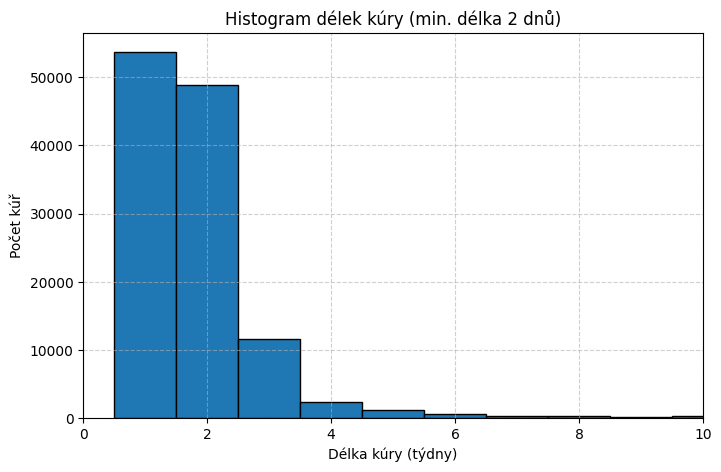

In [52]:
import math


def compute_cure_lengths(persons: list[Person]) -> list[int]:
    cure_lengths: list[int] = []

    for person in persons:
        # Filtrovat relevantní předpisy (INJ/INF)
        relevant = [
            p
            for p in person.prescriptions
            if p.lekova_forma_zkr
            and (
                p.lekova_forma_zkr.startswith("INJ")
                or p.lekova_forma_zkr.startswith("INF")
            )
            and p.lekova_forma  # musí mít vyplněnou formu
        ]

        if not relevant:
            continue

        # Seřadit podle data
        relevant.sort(key=lambda p: p.date)

        # Seskupit podle lekova_forma
        grouped: dict[str | None, list[Prescription]] = {}
        for pres in relevant:
            grouped.setdefault(pres.lekova_forma, []).append(pres)

        # Zpracovat každou skupinu zvlášť
        for forma, group in grouped.items():
            group.sort(key=lambda p: p.date)
            current_start = group[0].date
            last_date = group[0].date

            for p in group[1:]:
                gap = (p.date - last_date).days
                if gap > 7:
                    # nová kúra
                    cure_lengths.append((last_date - current_start).days + 1)
                    current_start = p.date
                last_date = p.date

            # poslední kúra
            cure_lengths.append((last_date - current_start).days + 1)

    return cure_lengths


def plot_cure_length_histogram(
    cure_lengths: list[int], by: str = "days", min_length: int = 2
):
    filtered = [d for d in cure_lengths if d >= min_length]

    plt.figure(figsize=(8, 5))

    if by == "weeks":
        # Převést na týdny zaokrouhlením nahoru (např. 8 dní → 2 týdny)
        week_lengths = [math.ceil(d / 7) for d in filtered]
        max_weeks = 10
        # max_weeks = max(week_lengths)
        bins = range(1, max_weeks + 2)  # jeden bin na každý týden
        plt.hist(week_lengths, bins=bins, edgecolor="black", align="left")
        plt.xlabel("Délka kúry (týdny)")
        plt.xlim(0, max_weeks)
    else:
        max_days = max(filtered)
        bins = range(1, max_days + 2)  # jeden bin na každý den
        plt.hist(filtered, bins=bins, edgecolor="black", align="left")
        plt.xlabel("Délka kúry (dny)")
        plt.xlim(0, 20)

    plt.ylabel("Počet kúř")
    plt.title(f"Histogram délek kúry (min. délka {min_length} dnů)")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()


cure_lengths = compute_cure_lengths(persons)
plot_cure_length_histogram(cure_lengths, by="weeks")  # nebo "weeks"

In [ ]:
ROZHODNE_DATUM = date(2021, 6, 18)
ZACATEK_POJISTENI = date(2015, 1, 1)
KONEC_POJISTENI = date(2023, 12, 31)


num_of_persons = 0
num_of_alive_persons = 0
num_of_all_time_insured_persons = 0
num_of_16_to_29_year_old_persons = 0
num_of_vax_persons = 0
num_of_valid_vax_persons = 0
num_of_prescriptions = 0
num_of_valid_prescriptions = 0

vax_num_of_prescriptions_before = 0
vax_num_of_prescriptions_after = 0
novax_num_of_prescriptions_before = 0
novax_num_of_prescriptions_after = 0

vax_num_of_pred_eq_before = 0
vax_num_of_pred_eq_after = 0
novax_num_of_pred_eq_before = 0
novax_num_of_pred_eq_after = 0

vax_num_of_first_prescription_before = 0
vax_num_of_first_prescription_after = 0
novax_num_of_first_prescription_before = 0
novax_num_of_first_prescription_after = 0

num_of_novax_prescriptions = 0
num_of_valid_novax_prescriptions = 0


for person in persons:
    num_of_persons += 1
    if not person.died_at:
        num_of_alive_persons += 1
        if (
            person.zahajeni_pojisteni < ZACATEK_POJISTENI
            and person.ukonceni_pojisteni > KONEC_POJISTENI
        ):
            num_of_all_time_insured_persons += 1

            if person.born_at.year >= 1992 and person.born_at.year <= 2005:
                num_of_16_to_29_year_old_persons += 1

                if person.vaccines:
                    num_of_vax_persons += 1

                    first_dose_vaccine = person.vaccines[0]
                    if first_dose_vaccine.date >= ROZHODNE_DATUM - timedelta(
                        days=14
                    ) and first_dose_vaccine.date <= ROZHODNE_DATUM + timedelta(
                        days=14
                    ):
                        num_of_valid_vax_persons += 1

                        for prescription in person.prescriptions:
                            if (
                                prescription.prescription_type
                                == PrescriptionType.IMUNOSUPRESSIVE
                                or prescription.prescription_type
                                == PrescriptionType.TEST
                            ):
                                continue
                            num_of_prescriptions += 1

                            if (
                                prescription.date
                                >= first_dose_vaccine.date - timedelta(days=365)
                                and prescription.date
                                < first_dose_vaccine.date + timedelta(days=365)
                            ):
                                num_of_valid_prescriptions += 1

                                if prescription.date < first_dose_vaccine.date:
                                    vax_num_of_prescriptions_before += 1
                                    vax_num_of_pred_eq_before += (
                                        prescription.prednison_equiv
                                    )
                                else:
                                    vax_num_of_prescriptions_after += 1
                                    vax_num_of_pred_eq_after += (
                                        prescription.prednison_equiv
                                    )

                        first_corticoide_prescription = (
                            find_first_corticoide_prescription(person.prescriptions)
                        )
                        if first_corticoide_prescription:
                            if (
                                first_corticoide_prescription.date
                                >= first_dose_vaccine.date - timedelta(days=365)
                                and first_corticoide_prescription.date
                                < first_dose_vaccine.date + timedelta(days=365)
                            ):
                                if (
                                    first_corticoide_prescription.date
                                    < first_dose_vaccine.date
                                ):
                                    vax_num_of_first_prescription_before += 1
                                else:
                                    vax_num_of_first_prescription_after += 1

                else:
                    for prescription in person.prescriptions:
                        if (
                            prescription.prescription_type
                            == PrescriptionType.IMUNOSUPRESSIVE
                            or prescription.prescription_type == PrescriptionType.TEST
                        ):
                            continue
                        num_of_novax_prescriptions += 1
                        if prescription.date >= ROZHODNE_DATUM - timedelta(
                            days=365
                        ) and prescription.date < ROZHODNE_DATUM + timedelta(days=365):
                            num_of_valid_novax_prescriptions += 1
                            if prescription.date < ROZHODNE_DATUM:
                                novax_num_of_prescriptions_before += 1
                                novax_num_of_pred_eq_before += (
                                    prescription.prednison_equiv
                                )
                            else:
                                novax_num_of_prescriptions_after += 1
                                novax_num_of_pred_eq_after += (
                                    prescription.prednison_equiv
                                )

                    first_corticoide_prescription = find_first_corticoide_prescription(
                        person.prescriptions
                    )
                    if first_corticoide_prescription:
                        if (
                            first_corticoide_prescription.date
                            >= ROZHODNE_DATUM - timedelta(days=365)
                            and first_corticoide_prescription.date
                            < ROZHODNE_DATUM + timedelta(days=365)
                        ):
                            if first_corticoide_prescription.date < ROZHODNE_DATUM:
                                novax_num_of_first_prescription_before += 1
                            else:
                                novax_num_of_first_prescription_after += 1

print(f"Number of persons: {num_of_persons}")
print(f"Number of alive persons: {num_of_alive_persons}")
print(f"Number of all-time insured persons: {num_of_all_time_insured_persons}")
print(f"Number of 16-29 year old persons: {num_of_16_to_29_year_old_persons}")
print(f"Number of vax persons: {num_of_vax_persons}")
print(f"Number of valid vax persons: {num_of_valid_vax_persons}")
print(f"Number of prescriptions: {num_of_prescriptions}")
print(f"Number of valid prescriptions: {num_of_valid_prescriptions}")

print(f"Number of prescriptions before vax: {vax_num_of_prescriptions_before}")
print(f"Number of prescriptions after vax: {vax_num_of_prescriptions_after}")
print(f"Number of prescriptions before vax: {novax_num_of_prescriptions_before}")
print(f"Number of prescriptions after vax: {novax_num_of_prescriptions_after}")

print(f"Number of prednison equivalents before vax: {vax_num_of_pred_eq_before}")
print(f"Number of prednison equivalents after vax: {vax_num_of_pred_eq_after}")
print(f"Number of prednison equivalents before vax: {novax_num_of_pred_eq_before}")
print(f"Number of prednison equivalents after vax: {novax_num_of_pred_eq_after}")

print(
    f"Number of first prescriptions before vax: {vax_num_of_first_prescription_before}"
)
print(f"Number of first prescriptions after vax: {vax_num_of_first_prescription_after}")
print(
    f"Number of first prescriptions before vax: {novax_num_of_first_prescription_before}"
)
print(
    f"Number of first prescriptions after vax: {novax_num_of_first_prescription_after}"
)

print(f"Number of novax prescriptions: {num_of_novax_prescriptions}")
print(f"Number of valid novax prescriptions: {num_of_valid_novax_prescriptions}")

Number of persons: 1570780
Number of alive persons: 1466955
Number of all-time insured persons: 999162
Number of 16-29 year old persons: 170596
Number of vax persons: 105878
Number of valid vax persons: 36093
Number of prescriptions: 16039
Number of valid prescriptions: 4182
Number of prescriptions before vax: 1919
Number of prescriptions after vax: 2263
Number of prescriptions before vax: 3062
Number of prescriptions after vax: 3650
Number of prednison equivalents before vax: 419749.25
Number of prednison equivalents after vax: 534582.1875
Number of prednison equivalents before vax: 921593.34375
Number of prednison equivalents after vax: 1045459.0
Number of first prescriptions before vax: 760
Number of first prescriptions after vax: 849
Number of first prescriptions before vax: 1108
Number of first prescriptions after vax: 1306
Number of novax prescriptions: 26807
Number of valid novax prescriptions: 6712


In [3]:
NEJVETSI_VYOCKOVANI_ROZHODNE_DATA = {
    AgeCohort._12_15: date(2021, 7, 28),
    AgeCohort._16_29: date(2021, 6, 9),
    AgeCohort._30_49: date(2021, 5, 19),
    AgeCohort._50_59: date(2021, 5, 10),
}

OTEVRENI_NEJMLADSI_CASTI_ROZHODNE_DATA = {
    AgeCohort._12_15: date(2021, 7, 1) + timedelta(days=14),
    AgeCohort._16_29: date(2021, 6, 4) + timedelta(days=14),
    AgeCohort._30_49: date(2021, 5, 26) + timedelta(days=14),
    AgeCohort._50_59: date(2021, 5, 5) + timedelta(days=14),
}

OTEVRENI_NEJSTARSI_CASTI_ROZHODNE_DATA = {
    AgeCohort._12_15: date(2021, 7, 1) + timedelta(days=14),
    AgeCohort._16_29: date(2021, 6, 4) + timedelta(days=14),
    AgeCohort._30_49: date(2021, 5, 10) + timedelta(days=14),
    AgeCohort._50_59: date(2021, 4, 24) + timedelta(days=14),
}

{<AgeCohort.IRRELEVANT: 'irrelevant'>: {'date': datetime.date(2021, 4, 29), 'count': 5313}, <AgeCohort._30_49: '30-49'>: {'date': datetime.date(2021, 5, 19), 'count': 4973}, <AgeCohort._12_15: '12-15'>: {'date': datetime.date(2021, 7, 28), 'count': 624}, <AgeCohort._16_29: '16-29'>: {'date': datetime.date(2021, 6, 9), 'count': 2066}, <AgeCohort._50_59: '50-59'>: {'date': datetime.date(2021, 5, 10), 'count': 4592}}


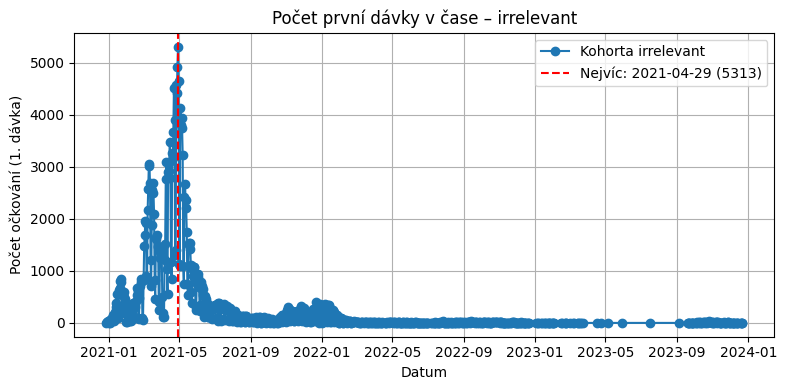

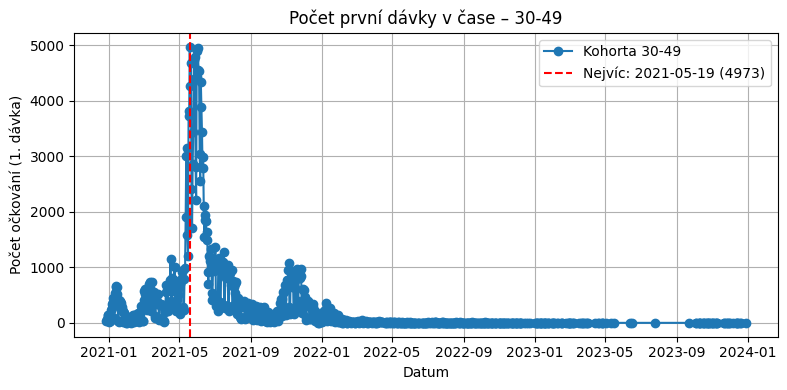

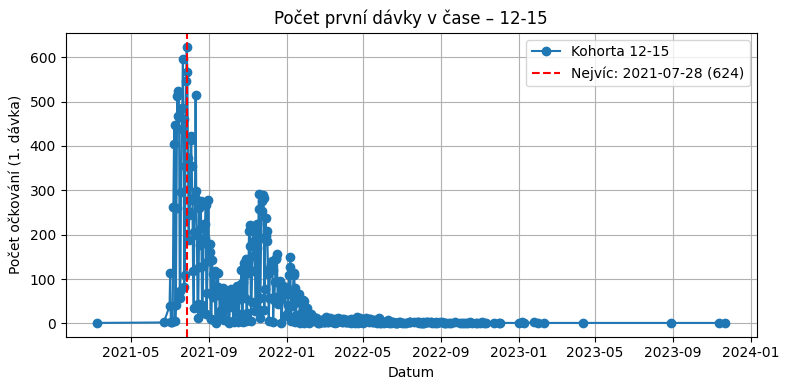

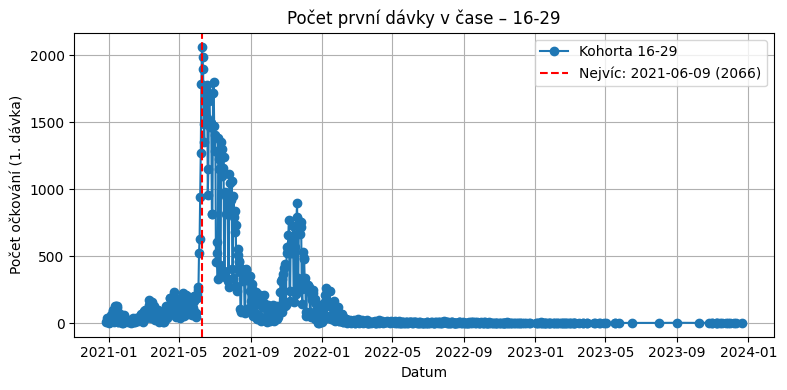

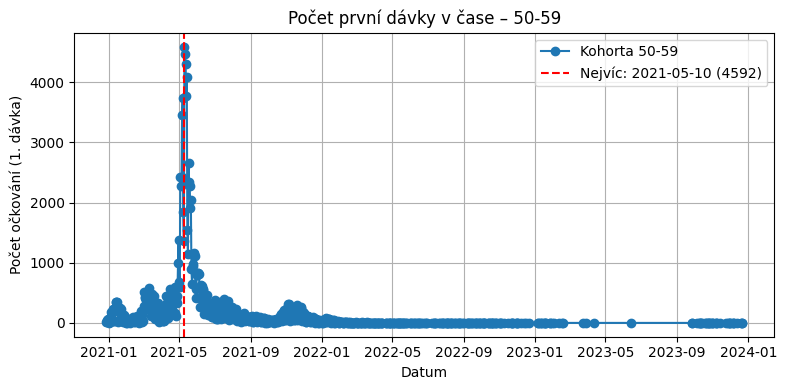

In [ ]:
cohort_counts = defaultdict(Counter)

for person in persons:
    age_cohort = calculate_age_cohort(person)
    if not person.vaccines:
        continue
    first_vax = person.vaccines[0]
    cohort_counts[age_cohort][first_vax.date] += 1

# Najdeme datum s nejvyšším počtem pro každou kohortu
peak_by_cohort = {}
for cohort, counts in cohort_counts.items():
    peak_date, peak_count = counts.most_common(1)[0]
    peak_by_cohort[cohort] = {"date": peak_date, "count": peak_count}

print(peak_by_cohort)


def plot_first_dose_trends(persons):
    """Vykreslí počet první dávky vakcín podle věkových kohort a označí den s nejvyšším počtem."""
    cohort_counts = defaultdict(Counter)

    for person in persons:
        cohort = calculate_age_cohort(person)
        for vaccine in person.vaccines:
            if vaccine.dose_number == 1:
                cohort_counts[cohort][vaccine.date] += 1

    for cohort, counts in cohort_counts.items():
        if not counts:
            continue  # pokud v dané kohortě nejsou žádné první dávky

        dates = sorted(counts.keys())
        values = [counts[d] for d in dates]

        # Najdeme datum s nejvyšším počtem
        peak_date, peak_value = max(counts.items(), key=lambda x: x[1])

        plt.plot(dates, values, marker="o", label=f"Kohorta {cohort}")
        plt.axvline(
            peak_date,
            color="red",
            linestyle="--",
            label=f"Nejvíc: {peak_date} ({peak_value})",
        )
        plt.title(f"Počet první dávky v čase – {cohort}")
        plt.xlabel("Datum")
        plt.ylabel("Počet očkování (1. dávka)")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


plot_first_dose_trends(persons)

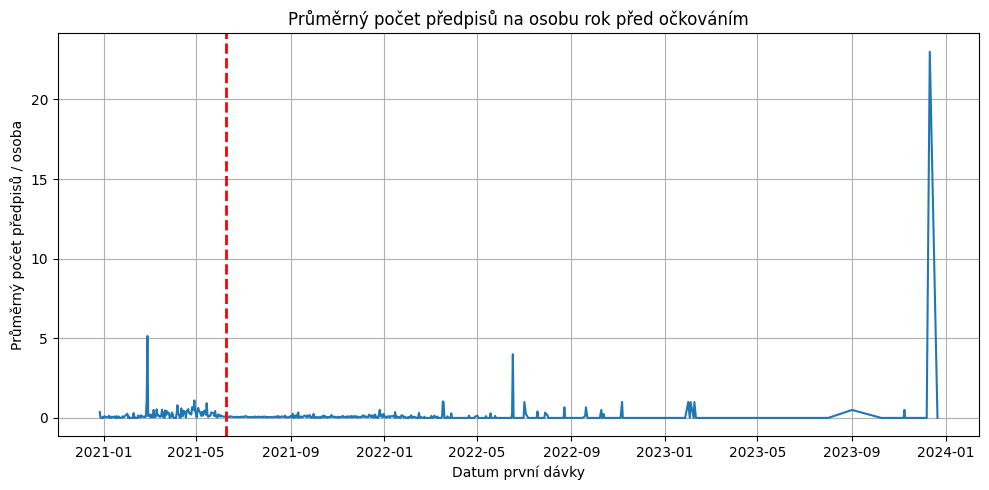

In [6]:
suma_predpisu_rok_pred_vakcinaci = {}
pocet_vyockovanych_vakcin = {}
for person in persons:
    if person.died_at or not person.vaccines:
        continue
    if calculate_age_cohort(person) != AgeCohort._16_29:
        continue

    first_vax = person.vaccines[0]

    pocet_vyockovanych_vakcin[first_vax.date] = (
        pocet_vyockovanych_vakcin.get(first_vax.date, 0) + 1
    )

    pocet_prepisu_rok_pred = 0
    for prescription in person.prescriptions:
        relative_days = (prescription.date - first_vax.date).days
        if not (-365 <= relative_days < 0):
            continue
        pocet_prepisu_rok_pred += 1

    suma_predpisu_rok_pred_vakcinaci[first_vax.date] = (
        suma_predpisu_rok_pred_vakcinaci.get(first_vax.date, 0) + pocet_prepisu_rok_pred
    )

prumer_predpisu_na_osobu = {}

for vax_date in suma_predpisu_rok_pred_vakcinaci:
    suma = suma_predpisu_rok_pred_vakcinaci[vax_date]
    pocet = pocet_vyockovanych_vakcin.get(vax_date, 0)
    if pocet > 0:
        prumer_predpisu_na_osobu[vax_date] = suma / pocet

# seřadíme podle data (pro správné zobrazení na ose X)
sorted_dates = sorted(prumer_predpisu_na_osobu.keys())
values = [prumer_predpisu_na_osobu[d] for d in sorted_dates]

# vykreslení
plt.figure(figsize=(10, 5))
plt.plot(sorted_dates, values)
highlight_date = date(2021, 6, 9)
plt.axvline(highlight_date, color="red", linestyle="--", linewidth=2, label="9.6.2021")  # type: ignore[arg-type]

plt.title("Průměrný počet předpisů na osobu rok před očkováním")
plt.xlabel("Datum první dávky")
plt.ylabel("Průměrný počet předpisů / osoba")
plt.grid(True)
plt.tight_layout()
plt.show()

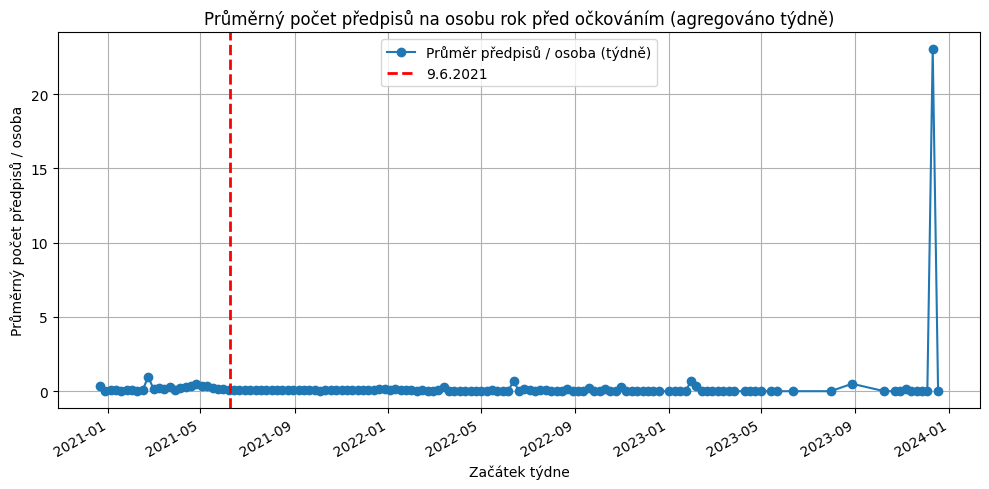

In [7]:
import matplotlib.pyplot as plt
from datetime import date, timedelta
from collections import defaultdict

# výpočet průměrů po dnech (stejně jako dřív)
prumer_predpisu_na_osobu = {}
for vax_date in suma_predpisu_rok_pred_vakcinaci:
    suma = suma_predpisu_rok_pred_vakcinaci[vax_date]
    pocet = pocet_vyockovanych_vakcin.get(vax_date, 0)
    if pocet > 0:
        prumer_predpisu_na_osobu[vax_date] = suma / pocet


# pomocná funkce na začátek týdne (pondělí)
def start_of_week(d: date) -> date:
    return d - timedelta(days=d.weekday())


# agregace na týdny
tydenni_data = defaultdict(list)
for d, val in prumer_predpisu_na_osobu.items():
    week = start_of_week(d)
    tydenni_data[week].append(val)

# průměrná hodnota za týden
tydenni_prumer = {week: sum(vals) / len(vals) for week, vals in tydenni_data.items()}

# seřadíme podle data
sorted_weeks = sorted(tydenni_prumer.keys())
values = [tydenni_prumer[w] for w in sorted_weeks]

# vykreslení
plt.figure(figsize=(10, 5))
plt.plot(sorted_weeks, values, marker="o", label="Průměr předpisů / osoba (týdně)")

# čára 9.6.2021
highlight_date = date(2021, 6, 9)
plt.axvline(highlight_date, color="red", linestyle="--", linewidth=2, label="9.6.2021")  # type: ignore[arg-type]

# popisky
plt.title("Průměrný počet předpisů na osobu rok před očkováním (agregováno týdně)")
plt.xlabel("Začátek týdne")
plt.ylabel("Průměrný počet předpisů / osoba")
plt.legend()
plt.grid(True)
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

15
33


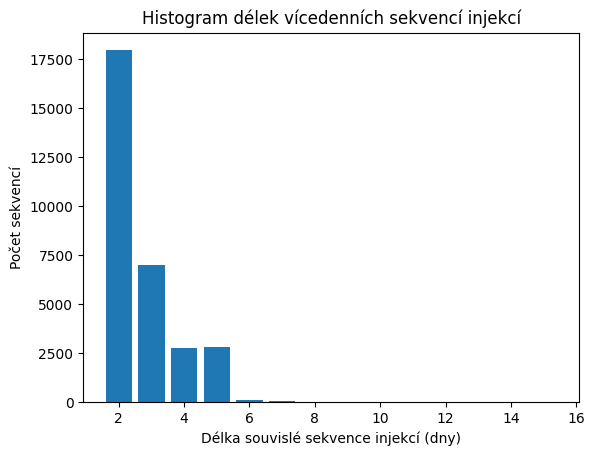

In [ ]:
def get_injection_streaks(persons) -> list[int]:
    streaks = []

    for person in persons:
        injections = sorted(
            [p for p in person.prescriptions if is_injection(p.lekova_forma)],
            key=lambda p: p.date,
        )

        if not injections:
            continue

        streak_length = 1
        for prev, curr in zip(injections, injections[1:]):
            if (curr.date - prev.date).days == 1:
                streak_length += 1
            else:
                if streak_length > 1:
                    streaks.append(streak_length)
                streak_length = 1

        if streak_length > 1:
            streaks.append(streak_length)

    return streaks


def plot_streak_histogram(streaks: list[int]):
    if not streaks:
        print("Žádné vícedenní sekvence injekcí.")
        return

    counter = Counter(streaks)
    plt.bar(list(counter.keys()), list(counter.values()))
    plt.xlabel("Délka souvislé sekvence injekcí (dny)")
    plt.ylabel("Počet sekvencí")
    plt.title("Histogram délek vícedenních sekvencí injekcí")
    plt.show()


# --- příklad použití ---
streaks = get_injection_streaks(persons)
print(max(streaks))
plot_streak_histogram(streaks)

In [4]:
ROZHODNE_DATA_OPTIONS = {
    "nejvice_vyočkovaných": NEJVETSI_VYOCKOVANI_ROZHODNE_DATA,
    "otevreni_nejmladsi": OTEVRENI_NEJMLADSI_CASTI_ROZHODNE_DATA,
    "otevreni_nejstarsi": OTEVRENI_NEJSTARSI_CASTI_ROZHODNE_DATA,
}

PERIODA_OPTIONS = {"+-7": 7, "+-14": 14, "+-30": 30}

In [5]:
import polars as pl
from datetime import date, timedelta


def calculate_option(rozhodne_data, age_cohort, perioda) -> pl.DataFrame:
    ZACATEK_POJISTENI = date(2015, 1, 1)
    KONEC_POJISTENI = date(2023, 12, 31)
    SLEDOVANE_OBDOBI = 365
    rozhodne_datum = rozhodne_data[age_cohort]

    # Initialize counters
    vax_num_of_prescriptions_before = 0
    vax_num_of_prescriptions_after = 0
    novax_num_of_prescriptions_before = 0
    novax_num_of_prescriptions_after = 0

    vax_num_of_pred_eq_before = 0
    vax_num_of_pred_eq_after = 0
    novax_num_of_pred_eq_before = 0
    novax_num_of_pred_eq_after = 0

    vax_num_of_first_prescription_before = 0
    vax_num_of_first_prescription_after = 0
    novax_num_of_first_prescription_before = 0
    novax_num_of_first_prescription_after = 0

    ages_vax = []
    ages_novax = []

    for person in persons:
        if not person.died_at or person.died_at > KONEC_POJISTENI:
            if (
                person.zahajeni_pojisteni <= ZACATEK_POJISTENI
                and person.ukonceni_pojisteni >= KONEC_POJISTENI
            ):
                if calculate_age_cohort(person) == age_cohort:
                    if person.vaccines:
                        first_dose_vaccine = person.vaccines[0]
                        if (
                            rozhodne_datum - timedelta(days=perioda)
                            <= first_dose_vaccine.date
                            <= rozhodne_datum + timedelta(days=perioda)
                        ):
                            ages_vax.append(person.born_at.year)
                            for prescription in person.prescriptions:
                                if (
                                    prescription.prescription_type
                                    == PrescriptionType.IMUNOSUPRESSIVE
                                ):
                                    continue
                                if (
                                    first_dose_vaccine.date
                                    - timedelta(days=SLEDOVANE_OBDOBI)
                                    <= prescription.date
                                    < first_dose_vaccine.date
                                    + timedelta(days=SLEDOVANE_OBDOBI)
                                ):
                                    if prescription.date < first_dose_vaccine.date:
                                        vax_num_of_prescriptions_before += 1
                                        vax_num_of_pred_eq_before += (
                                            prescription.prednison_equiv
                                        )
                                    else:
                                        vax_num_of_prescriptions_after += 1
                                        vax_num_of_pred_eq_after += (
                                            prescription.prednison_equiv
                                        )

                            first_corticoide_prescription = (
                                find_first_corticoide_prescription(person.prescriptions)
                            )
                            if first_corticoide_prescription and (
                                first_dose_vaccine.date
                                - timedelta(days=SLEDOVANE_OBDOBI)
                                <= first_corticoide_prescription.date
                                < first_dose_vaccine.date
                                + timedelta(days=SLEDOVANE_OBDOBI)
                            ):
                                if (
                                    first_corticoide_prescription.date
                                    < first_dose_vaccine.date
                                ):
                                    vax_num_of_first_prescription_before += 1
                                else:
                                    vax_num_of_first_prescription_after += 1
                    else:
                        ages_novax.append(person.born_at.year)
                        for prescription in person.prescriptions:
                            if (
                                prescription.prescription_type
                                == PrescriptionType.IMUNOSUPRESSIVE
                            ):
                                continue
                            if (
                                rozhodne_datum - timedelta(days=SLEDOVANE_OBDOBI)
                                <= prescription.date
                                < rozhodne_datum + timedelta(days=SLEDOVANE_OBDOBI)
                            ):
                                if prescription.date < rozhodne_datum:
                                    novax_num_of_prescriptions_before += 1
                                    novax_num_of_pred_eq_before += (
                                        prescription.prednison_equiv
                                    )
                                else:
                                    novax_num_of_prescriptions_after += 1
                                    novax_num_of_pred_eq_after += (
                                        prescription.prednison_equiv
                                    )

                        first_corticoide_prescription = (
                            find_first_corticoide_prescription(person.prescriptions)
                        )
                        if first_corticoide_prescription and (
                            rozhodne_datum - timedelta(days=SLEDOVANE_OBDOBI)
                            <= first_corticoide_prescription.date
                            < rozhodne_datum + timedelta(days=SLEDOVANE_OBDOBI)
                        ):
                            if first_corticoide_prescription.date < rozhodne_datum:
                                novax_num_of_first_prescription_before += 1
                            else:
                                novax_num_of_first_prescription_after += 1

    # ✅ Return results as a single-row Polars DataFrame
    return pl.DataFrame(
        {
            "age_cohort": [age_cohort],
            "perioda": [perioda],
            "rozhodne_datum": [rozhodne_datum],
            # ----
            "vax_num_of_prescriptions_before": [vax_num_of_prescriptions_before],
            "vax_num_of_prescriptions_after": [vax_num_of_prescriptions_after],
            "novax_num_of_prescriptions_before": [novax_num_of_prescriptions_before],
            "novax_num_of_prescriptions_after": [novax_num_of_prescriptions_after],
            "vax_prescriptions_after/before": [
                vax_num_of_prescriptions_after / vax_num_of_prescriptions_before
            ],
            "novax_prescriptions_after/before": [
                novax_num_of_prescriptions_after / novax_num_of_prescriptions_before
            ],
            "prescription_difference": [
                vax_num_of_prescriptions_after / vax_num_of_prescriptions_before
                - novax_num_of_prescriptions_after / novax_num_of_prescriptions_before
            ],
            # ----
            "vax_num_of_pred_eq_before": [vax_num_of_pred_eq_before],
            "vax_num_of_pred_eq_after": [vax_num_of_pred_eq_after],
            "novax_num_of_pred_eq_before": [novax_num_of_pred_eq_before],
            "novax_num_of_pred_eq_after": [novax_num_of_pred_eq_after],
            "vax_pred_eqafter/before": [
                vax_num_of_pred_eq_after / vax_num_of_pred_eq_before
            ],
            "novax_pred_eqafter/before": [
                novax_num_of_pred_eq_after / novax_num_of_pred_eq_before
            ],
            "pred_eq_difference": [
                vax_num_of_pred_eq_after / vax_num_of_pred_eq_before
                - novax_num_of_pred_eq_after / novax_num_of_pred_eq_before
            ],
            # ----
            "vax_num_of_first_prescription_before": [
                vax_num_of_first_prescription_before
            ],
            "vax_num_of_first_prescription_after": [
                vax_num_of_first_prescription_after
            ],
            "novax_num_of_first_prescription_before": [
                novax_num_of_first_prescription_before
            ],
            "novax_num_of_first_prescription_after": [
                novax_num_of_first_prescription_after
            ],
            "vax_first_prescr_after/before": [
                vax_num_of_first_prescription_after
                / vax_num_of_first_prescription_before
            ],
            "novax_first_prescr_after/before": [
                novax_num_of_first_prescription_after
                / novax_num_of_first_prescription_before
            ],
            "first_prescr_difference": [
                vax_num_of_first_prescription_after
                / vax_num_of_first_prescription_before
                - novax_num_of_first_prescription_after
                / novax_num_of_first_prescription_before
            ],
            # ----
            "vax_average_age": [sum(ages_vax) / len(ages_vax)],
            "novax_average_age": [sum(ages_novax) / len(ages_novax)],
        }
    )

In [6]:
results = []

for option_name, rozhodne_data in ROZHODNE_DATA_OPTIONS.items():
    for period_label, perioda in PERIODA_OPTIONS.items():
        for age_cohort in AgeCohort:
            if age_cohort == AgeCohort.IRRELEVANT:
                continue
            df = calculate_option(rozhodne_data, age_cohort, perioda)
            df = df.with_columns(
                [
                    pl.lit(option_name).alias("rozhodne_data_option"),
                    pl.lit(period_label).alias("period_label"),
                ]
            )
            results.append(df)

final_df = pl.concat(results, how="vertical")

In [7]:
final_df.write_csv("out.csv")